# SARIMA

SARIMA — Seasonal AutoRegressive Integrated Moving Average — is the workhorse linear model for series with autocorrelation, trend, and seasonality. Generating from a *known* `(p, d, q)(P, D, Q)` specification lets you confirm a model recovers the order you put in, or build panels with a precise, well-understood dependence structure.

::: {.callout-note}
## The model

An ARIMA(p, d, q) process combines `p` autoregressive lags, `d` orders of differencing (for trend / unit roots), and `q` moving-average lags; the seasonal part `(P, D, Q)` repeats that structure at the seasonal period. Set the orders and coefficients to dial in anything from white noise to a strongly seasonal, integrated series.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import SARIMAGenerator

## Example 1: Basic SARIMA(2,1,1)(1,1,1)_7

A SARIMA model with weekly seasonality, suitable for daily data.

In [ ]:
params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "p": 2,
    "d": 1,
    "q": 1,
    "P": 1,
    "D": 1,
    "Q": 1,
    "seasonal_period": 7,
    "noise_std": 2.0,
    "drift": 0.5,
    "seed": 42,
}

generator = SARIMAGenerator(engine="polars", **params)

### Model Information

Inspect the auto-generated model parameters and polynomial structure.

In [ ]:
model_info = generator.get_model_info()
print(f"Model: {model_info['model']}")
print(f"AR parameters: {model_info['ar_params']}")
print(f"MA parameters: {model_info['ma_params']}")
print(f"Seasonal AR parameters: {model_info['seasonal_ar_params']}")
print(f"Seasonal MA parameters: {model_info['seasonal_ma_params']}")
print(f"Drift: {model_info['drift']}")
print(f"Burn-in: {model_info['burn_in']}")
print(f"\nExpanded AR polynomial lags: {model_info['full_ar_polynomial_lags']}")
print(f"Expanded AR polynomial coeffs: {model_info['full_ar_polynomial_coeffs']}")

Model: SARIMA(2,1,1)(1,1,1)[7]
AR parameters: [0.2298813963661166, -0.04889724819835817]
MA parameters: [0.35859791991138246]
Seasonal AR parameters: [0.15789442324749114]
Seasonal MA parameters: [-0.40582265211235047]
Drift: 0.5
Burn-in: 100

Expanded AR polynomial lags: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Expanded AR polynomial coeffs: [0.2298813963661166, -0.04889724819835817, -0.0, -0.0, -0.0, -0.0, 0.15789442324749114, -0.036296990494555884, 0.007720602802669188]


### Generate and Inspect Data

In [ ]:
df = generator.generate(n_series=3)
print(f"Generated {df['unique_id'].n_unique()} time series")
print(f"Total observations: {len(df)}")
df.head(10)

Generated 3 time series
Total observations: 600


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,840.568595
"""0""",2000-01-02 00:00:00,849.409081
"""0""",2000-01-03 00:00:00,852.256521
"""0""",2000-01-04 00:00:00,864.365821
"""0""",2000-01-05 00:00:00,890.874551
"""0""",2000-01-06 00:00:00,904.417479
"""0""",2000-01-07 00:00:00,912.95809
"""0""",2000-01-08 00:00:00,927.189939
"""0""",2000-01-09 00:00:00,941.521277


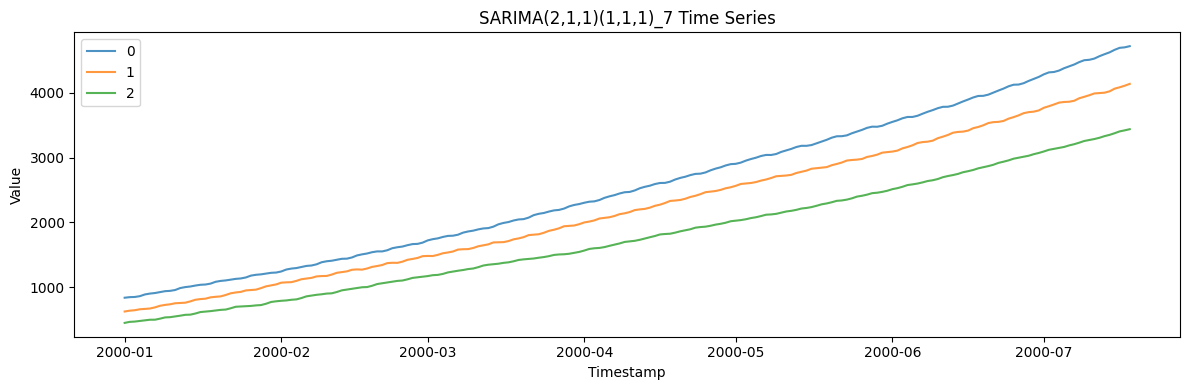

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("SARIMA(2,1,1)(1,1,1)_7 Time Series")
ax.legend()
plt.tight_layout()
plt.show()

### Statistics by Series

In [ ]:
df.group_by("unique_id").agg(
    [
        pl.col("y").count().alias("count"),
        pl.col("y").min().alias("min_value"),
        pl.col("y").max().alias("max_value"),
        pl.col("y").mean().alias("mean_value"),
        pl.col("y").std().alias("std_value"),
    ]
).sort("unique_id")

unique_id,count,min_value,max_value,mean_value,std_value
cat,u32,f64,f64,f64,f64
"""0""",200,840.568595,4716.719654,2557.619461,1132.631603
"""1""",200,628.393,4135.85017,2221.617457,1020.787936
"""2""",200,452.878919,3437.538082,1778.004889,857.699315


## Example 2: Stationary ARMA(1,1) with Custom Parameters

A stationary model with no differencing and explicit AR/MA coefficients.

In [ ]:
params_arma = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "p": 1,
    "d": 0,
    "q": 1,
    "P": 0,
    "D": 0,
    "Q": 0,
    "ar_params": [0.7],
    "ma_params": [0.3],
    "mean": 50.0,
    "noise_std": 1.0,
    "seed": 123,
}

generator_arma = SARIMAGenerator(engine="polars", **params_arma)
df_arma = generator_arma.generate(n_series=1)

print(f"Model: {generator_arma.get_model_info()['model']}")
print(f"Mean: {generator_arma.get_model_info()['mean']}")
print(f"Series mean: {df_arma['y'].mean():.2f}")
print(f"Series std: {df_arma['y'].std():.2f}")

Model: SARIMA(1,0,1)(0,0,0)[12]
Mean: 50.0
Series mean: 50.35
Series std: 1.61


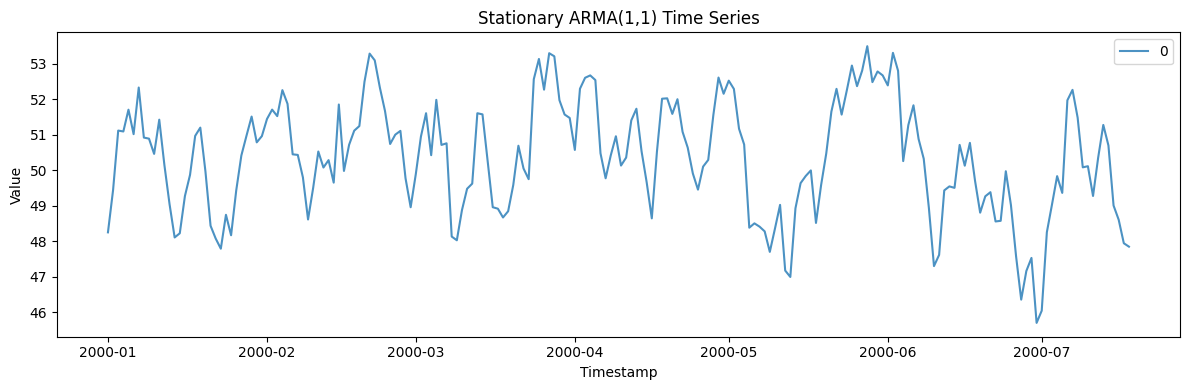

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_arma["unique_id"].unique().to_list():
    series = df_arma.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Stationary ARMA(1,1) Time Series")
ax.legend()
plt.tight_layout()
plt.show()

## Example 3: Pure Seasonal ARIMA(0,0,0)(1,1,1)_12

A purely seasonal model with monthly frequency and 12-month seasonality.

In [ ]:
params_seasonal = {
    "min_length": 100,
    "max_length": 100,
    "freq": "MS",
    "p": 0,
    "d": 0,
    "q": 0,
    "P": 1,
    "D": 1,
    "Q": 1,
    "seasonal_period": 12,
    "seasonal_ar_params": [0.5],
    "seasonal_ma_params": [0.3],
    "noise_std": 1.0,
    "seed": 456,
}

generator_seasonal = SARIMAGenerator(engine="polars", **params_seasonal)
df_seasonal = generator_seasonal.generate(n_series=1)

print(f"Model: {generator_seasonal.get_model_info()['model']}")
print("\nFirst 24 months:")
df_seasonal.head(24)

Model: SARIMA(0,0,0)(1,1,1)[12]

First 24 months:


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-0.846697
"""0""",2000-02-01 00:00:00,9.129227
"""0""",2000-03-01 00:00:00,7.281973
"""0""",2000-04-01 00:00:00,-1.550024
"""0""",2000-05-01 00:00:00,4.399888
…,…,…
"""0""",2001-08-01 00:00:00,-4.021058
"""0""",2001-09-01 00:00:00,0.429695
"""0""",2001-10-01 00:00:00,-3.538732


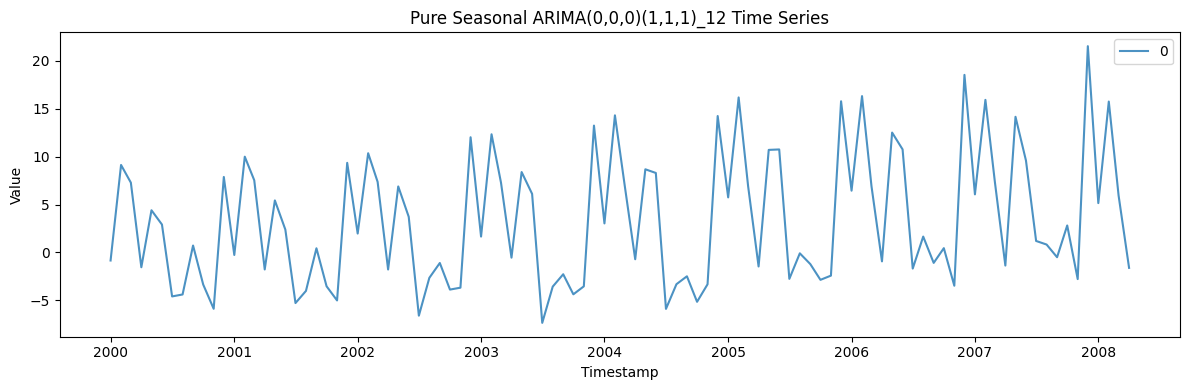

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_seasonal["unique_id"].unique().to_list():
    series = df_seasonal.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Pure Seasonal ARIMA(0,0,0)(1,1,1)_12 Time Series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [ETS](ets) — the exponential-smoothing counterpart for trend and seasonality.
- [Seasonal](seasonal) — a simpler fixed seasonal wave without ARMA dynamics.
- [Random walk](random_walk) — the special case ARIMA(0, 1, 0).

All orders and coefficients are documented in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::